# F1 Strategy Data Exploration

This notebook inspects the ingested datasets (cache/lake) to understand schema, distributions, and data quality before modeling.

In [20]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Paths where ingested data may live
PROJECT_ROOT = Path.cwd().resolve().parents[0]
DATA_LAKE = PROJECT_ROOT / "data" / "lake"
DATA_CACHE = PROJECT_ROOT / "data" / "cache"
DATA_JOBS = PROJECT_ROOT / "data" / "jobs"

DATA_DIRS = [p for p in [DATA_LAKE, DATA_CACHE, DATA_JOBS] if p.exists()]
print("Data roots:", DATA_DIRS)

Data roots: [WindowsPath('C:/Users/USER/Documents/Python Projects/f1-strategy/data/lake'), WindowsPath('C:/Users/USER/Documents/Python Projects/f1-strategy/data/cache'), WindowsPath('C:/Users/USER/Documents/Python Projects/f1-strategy/data/jobs')]


## Load ingested dataset

- Auto-detect a parquet/csv file under data lake/cache/jobs.
- Update `preferred_keywords` to prioritize specific tables (e.g., lap_times, pitstops).
- If multiple files exist, the first match is loaded; adjust path as needed.

In [21]:
from typing import Optional, Sequence
import re

# -------------------------------------------------------------------
# Load ALL laps_raw parquet files (multiple GPs/sessions)
# -------------------------------------------------------------------

def find_laps_parquet_files(roots: Sequence[Path]) -> list[Path]:
    """Find all laps_raw parquet files under data lake."""
    files: list[Path] = []
    for root in roots:
        # Target: data/lake/bronze/laps_raw/**/data.parquet
        files.extend(sorted(root.rglob("laps_raw/**/data.parquet")))
    return files


def extract_partition_metadata(filepath: Path) -> dict:
    """
    Extract year, gp_name, session_type from Hive-style partition path.
    Example path: .../laps_raw/year=2022/gp=Dutch_Grand_Prix/session=Q/data.parquet
    """
    path_str = filepath.as_posix()
    meta = {}
    
    year_match = re.search(r"year=(\d{4})", path_str)
    if year_match:
        meta["year"] = int(year_match.group(1))
    
    gp_match = re.search(r"gp=([^/]+)", path_str)
    if gp_match:
        meta["gp_name"] = gp_match.group(1).replace("_", " ")
    
    session_match = re.search(r"session=([^/]+)", path_str)
    if session_match:
        meta["session_type"] = session_match.group(1)
    
    return meta


def load_all_laps(roots: Sequence[Path], max_files: Optional[int] = None) -> pd.DataFrame:
    """
    Load all laps_raw parquet files and populate partition metadata columns.
    """
    files = find_laps_parquet_files(roots)
    if max_files:
        files = files[:max_files]
    
    print(f"Loading {len(files)} laps_raw parquet files...")
    
    dfs = []
    for f in files:
        try:
            part_df = pd.read_parquet(f)
            # Fill partition metadata from path
            meta = extract_partition_metadata(f)
            for col, val in meta.items():
                part_df[col] = val
            dfs.append(part_df)
        except Exception as e:
            print(f"  Skipped {f.name}: {e}")
    
    if not dfs:
        return pd.DataFrame()
    
    df = pd.concat(dfs, ignore_index=True)
    print(f"Loaded {len(df):,} total rows from {len(dfs)} files")
    return df


# Load all sessions
candidate_files = find_laps_parquet_files(DATA_DIRS)
print(f"Found {len(candidate_files)} laps_raw parquet files")

df = load_all_laps(DATA_DIRS)
display(df.head() if not df.empty else "No data loaded")

Found 337 laps_raw parquet files
Loading 337 laps_raw parquet files...
Loaded 182,404 total rows from 337 files


,session_id,year,gp_name,session_type,driver,driver_number,lap_number,lap_time_ms,sector1_ms,sector2_ms,sector3_ms,compound,stint,tyre_life,fresh_tyre,team,track_status,is_pit_lap,is_accurate,position,deleted,deleted_reason,fast_f1_generated,is_personal_best
0,661656503,2022,Abu Dhabi Grand Prix,FP1,RIC,3,1,NaN,NaN,55248.0,45347.0,HARD,1.0,1.0,1,McLaren,1,1,0,NaN,0,,0,0
1,661656503,2022,Abu Dhabi Grand Prix,FP1,RIC,3,2,102045.0,20125.0,42470.0,39450.0,HARD,1.0,2.0,1,McLaren,1,1,0,NaN,0,,0,0
2,661656503,2022,Abu Dhabi Grand Prix,FP1,RIC,3,3,NaN,NaN,41820.0,37341.0,HARD,2.0,3.0,0,McLaren,1,1,0,NaN,0,,0,0
3,661656503,2022,Abu Dhabi Grand Prix,FP1,RIC,3,4,90759.0,18427.0,38636.0,33696.0,HARD,2.0,4.0,0,McLaren,1,0,1,NaN,0,,0,1
4,661656503,2022,Abu Dhabi Grand Prix,FP1,RIC,3,5,89445.0,18153.0,38149.0,33143.0,HARD,2.0,5.0,0,McLaren,1,0,1,NaN,0,,0,1


## Helper filters and plotting utils

Convenience helpers to subset by grand prix/session/driver and plot lap-wise time series when columns exist.

In [22]:
def filter_session(
    frame: pd.DataFrame,
    grand_prix: Optional[str] = None,
    session: Optional[str] = None,
    driver: Optional[str] = None,
    year: Optional[int] = None,
):
    """Filter dataframe by GP, session type, driver, or year."""
    data = frame.copy()
    if grand_prix and "gp_name" in data.columns:
        data = data[data["gp_name"].str.contains(grand_prix, case=False, na=False)]
    if session and "session_type" in data.columns:
        data = data[data["session_type"].str.contains(session, case=False, na=False)]
    if driver and "driver" in data.columns:
        data = data[data["driver"].str.contains(driver, case=False, na=False)]
    if year and "year" in data.columns:
        data = data[data["year"] == year]
    return data


def filter_valid_laps(frame: pd.DataFrame) -> pd.DataFrame:
    """
    Filter for valid/accurate laps only.
    Excludes deleted laps and incomplete laps (is_accurate == True).
    """
    if "is_accurate" in frame.columns:
        valid = frame[frame["is_accurate"] == True].copy()
        print(f"Filtered to {len(valid):,} valid laps (from {len(frame):,} total)")
        return valid
    print("Warning: 'is_accurate' column not found, returning all laps")
    return frame


def flag_outliers_iqr(frame: pd.DataFrame, columns: list[str], multiplier: float = 1.5) -> pd.DataFrame:
    """
    Add outlier flag columns for specified numeric columns using IQR method.
    Creates new columns: {col}_outlier (bool) for each column.
    Does NOT remove data—just flags for downstream filtering.
    """
    df = frame.copy()
    for col in columns:
        if col not in df.columns or not pd.api.types.is_numeric_dtype(df[col]):
            continue
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        if pd.isna(iqr) or iqr == 0:
            df[f"{col}_outlier"] = False
            continue
        lower = q1 - multiplier * iqr
        upper = q3 + multiplier * iqr
        df[f"{col}_outlier"] = (df[col] < lower) | (df[col] > upper)
    return df


def plot_lap_time_series(frame: pd.DataFrame, value_col: str, title: str = None):
    """Plot lap-wise time series with optional driver hue."""
    if "lap_number" in frame.columns:
        x_col = "lap_number"
    elif "lap" in frame.columns:
        x_col = "lap"
    else:
        print("No lap column found for plotting.")
        return

    if value_col not in frame.columns:
        print(f"Missing {value_col} in dataframe.")
        return

    plt.figure(figsize=(12, 5))
    hue_col = "driver" if "driver" in frame.columns else None
    sns.lineplot(data=frame, x=x_col, y=value_col, hue=hue_col, legend=False)
    plt.title(title or f"{value_col} over laps")
    plt.xlabel(x_col)
    plt.ylabel(value_col)
    plt.show()


# Example usage:
# df_valid = filter_valid_laps(df)
# df_flagged = flag_outliers_iqr(df_valid, ["lap_time_ms", "sector1_ms", "sector2_ms", "sector3_ms"])
# filtered = filter_session(df_flagged, grand_prix="Bahrain", year=2022, driver="VER")

## Apply data cleaning: filter valid laps & flag outliers

- Filter to `is_accurate == True` to exclude deleted/incomplete laps
- Flag (not remove) outliers in sector times and lap times using IQR
- Show summary of filtering impact

In [23]:
# Apply valid lap filter
df_valid = filter_valid_laps(df)

# Flag outliers in timing columns (do NOT remove, just flag)
timing_cols = ["lap_time_ms", "sector1_ms", "sector2_ms", "sector3_ms"]
df_clean = flag_outliers_iqr(df_valid, timing_cols)

# Summary of outlier flags
outlier_cols = [c for c in df_clean.columns if c.endswith("_outlier")]
if outlier_cols:
    print("\nOutlier flags summary:")
    for col in outlier_cols:
        n_outliers = df_clean[col].sum()
        pct = n_outliers / len(df_clean) * 100
        print(f"  {col}: {n_outliers:,} ({pct:.2f}%)")

# Show partition metadata coverage
print("\nPartition metadata populated:")
for col in ["year", "gp_name", "session_type"]:
    if col in df_clean.columns:
        non_null = df_clean[col].notna().sum()
        print(f"  {col}: {non_null:,} non-null ({non_null/len(df_clean)*100:.1f}%)")
        print(f"    unique values: {df_clean[col].nunique()}")

# Use df_clean for downstream analysis
df = df_clean
display(df.head())

Filtered to 129,894 valid laps (from 182,404 total)

Outlier flags summary:
  lap_time_ms_outlier: 5,092 (3.92%)
  sector1_ms_outlier: 3,550 (2.73%)
  sector2_ms_outlier: 1,991 (1.53%)
  sector3_ms_outlier: 3,108 (2.39%)

Partition metadata populated:
  year: 129,894 non-null (100.0%)
    unique values: 3
  gp_name: 129,894 non-null (100.0%)
    unique values: 25
  session_type: 129,894 non-null (100.0%)
    unique values: 7


,session_id,year,gp_name,session_type,driver,driver_number,lap_number,lap_time_ms,sector1_ms,sector2_ms,sector3_ms,compound,stint,tyre_life,fresh_tyre,team,track_status,is_pit_lap,is_accurate,position,deleted,deleted_reason,fast_f1_generated,is_personal_best,lap_time_ms_outlier,sector1_ms_outlier,sector2_ms_outlier,sector3_ms_outlier
3,661656503,2022,Abu Dhabi Grand Prix,FP1,RIC,3,4,90759.0,18427.0,38636.0,33696.0,HARD,2.0,4.0,0,McLaren,1,0,1,NaN,0,,0,1,False,False,False,False
4,661656503,2022,Abu Dhabi Grand Prix,FP1,RIC,3,5,89445.0,18153.0,38149.0,33143.0,HARD,2.0,5.0,0,McLaren,1,0,1,NaN,0,,0,1,False,False,False,False
5,661656503,2022,Abu Dhabi Grand Prix,FP1,RIC,3,6,132859.0,23315.0,58746.0,50798.0,HARD,2.0,6.0,0,McLaren,1,0,1,NaN,0,,0,0,True,False,True,True
6,661656503,2022,Abu Dhabi Grand Prix,FP1,RIC,3,7,89035.0,18114.0,38152.0,32769.0,HARD,2.0,7.0,0,McLaren,1,0,1,NaN,0,,0,1,False,False,False,False
7,661656503,2022,Abu Dhabi Grand Prix,FP1,RIC,3,8,132252.0,24273.0,58161.0,49818.0,HARD,2.0,8.0,0,McLaren,1,0,1,NaN,0,,0,0,True,False,True,True


## Inspect schema and metadata

Quick view of columns, dtypes, size, and unique counts for likely categorical columns.

In [24]:
if df is None:
    raise RuntimeError("No dataframe loaded; set `selected_file` to a dataset before continuing.")

mem_bytes = df.memory_usage(deep=True).sum()
print(f"Rows: {len(df):,}, Columns: {df.shape[1]}")
print(f"Memory usage: {mem_bytes/1e6:.2f} MB")

schema = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.notna().sum(),
    "nulls": df.isna().sum(),
})
schema["null_pct"] = (schema["nulls"] / len(df) * 100).round(2)

# Candidate categoricals: object columns or low-cardinality numerics
cat_like_cols = [
    c
    for c in df.columns
    if df[c].dtype == "object" or df[c].nunique(dropna=False) <= 50
]

unique_counts = df[cat_like_cols].nunique(dropna=False).sort_values(ascending=False)

display(schema)
print("\nUnique counts (cat-like):")
display(unique_counts)

Rows: 129,894, Columns: 28
Memory usage: 74.81 MB


,dtype,non_null,nulls,null_pct
session_id,int64,129894,0,0.00
year,int64,129894,0,0.00
gp_name,object,129894,0,0.00
session_type,object,129894,0,0.00
driver,object,129894,0,0.00
driver_number,object,129894,0,0.00
lap_number,int64,129894,0,0.00
lap_time_ms,float64,129894,0,0.00
sector1_ms,float64,129894,0,0.00
sector2_ms,float64,129894,0,0.00



Unique counts (cat-like):


deleted_reason         659
driver                  55
driver_number           48
gp_name                 25
position                21
team                    12
stint                   12
compound                10
session_type             7
track_status             4
year                     3
deleted                  2
fresh_tyre               2
sector2_ms_outlier       2
sector1_ms_outlier       2
is_personal_best         2
lap_time_ms_outlier      2
sector3_ms_outlier       2
is_pit_lap               1
is_accurate              1
fast_f1_generated        1
dtype: int64

## Summary statistics

Numeric and categorical summaries with skew/kurtosis for distribution shape.

In [25]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

if numeric_cols:
    num_summary = df[numeric_cols].describe().T
    num_summary["skew"] = df[numeric_cols].skew()
    num_summary["kurtosis"] = df[numeric_cols].kurtosis()
    display(num_summary)
else:
    print("No numeric columns found.")

if cat_cols:
    cat_summary = df[cat_cols].describe(include="all").T
    display(cat_summary)
else:
    print("No categorical columns found.")

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
session_id,129894.0,4.886924e+08,2.834204e+08,2376357.0,256457490.0,474130539.0,7.377439e+08,999684744.0,0.047303,-1.179150
year,129894.0,2.023020e+03,8.263006e-01,2022.0,2022.0,2023.0,2.024000e+03,2024.0,-0.037766,-1.534413
lap_number,129894.0,2.189698e+01,1.675096e+01,1.0,9.0,17.0,3.100000e+01,78.0,0.979000,0.127444
lap_time_ms,129894.0,9.221028e+04,1.556245e+04,64314.0,80909.0,89719.0,9.977900e+04,149998.0,1.097075,1.310578
sector1_ms,129894.0,2.819598e+04,6.677139e+03,16251.0,23924.0,28423.0,3.150500e+04,92283.0,0.733451,1.886324
sector2_ms,129894.0,3.580661e+04,8.327922e+03,17289.0,30003.0,34674.5,4.121000e+04,94336.0,0.611089,0.962589
sector3_ms,129894.0,2.820769e+04,7.591027e+03,16061.0,23028.0,26506.0,3.217775e+04,91652.0,1.481494,4.360346
stint,129882.0,2.312653e+00,1.244799e+00,1.0,1.0,2.0,3.000000e+00,11.0,0.927175,0.696266
tyre_life,129428.0,1.141950e+01,8.899502e+00,1.0,5.0,9.0,1.600000e+01,78.0,1.622275,4.151810
fresh_tyre,129894.0,6.716861e-01,4.696015e-01,0.0,0.0,1.0,1.000000e+00,1.0,-0.731211,-1.465354


,count,unique,top,freq
gp_name,129894,25,Monaco Grand Prix,7869
session_type,129894,7,R,64479
driver,129894,55,RUS,6809
driver_number,129894,48,63,6809
compound,129894,10,MEDIUM,45124
team,129894,12,Mercedes,13463
track_status,129894,4,1,123603
deleted_reason,129894,659,,128438


## Visualize distributions

Histograms/boxplots for numeric fields and bar charts for categorical counts.

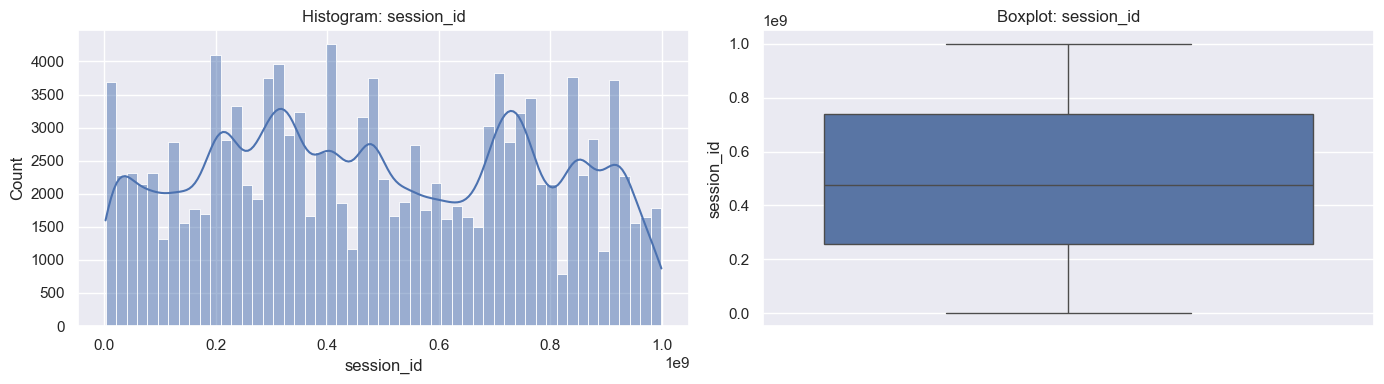

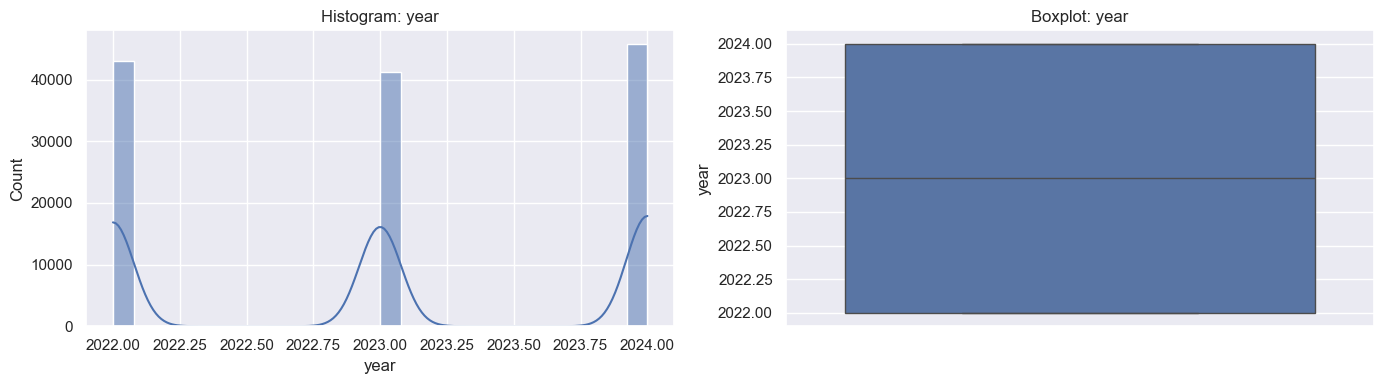

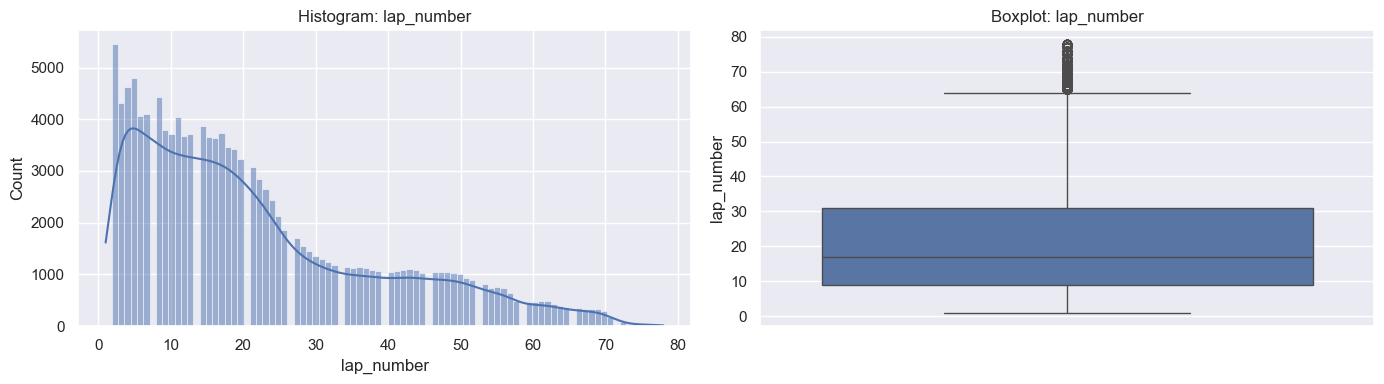

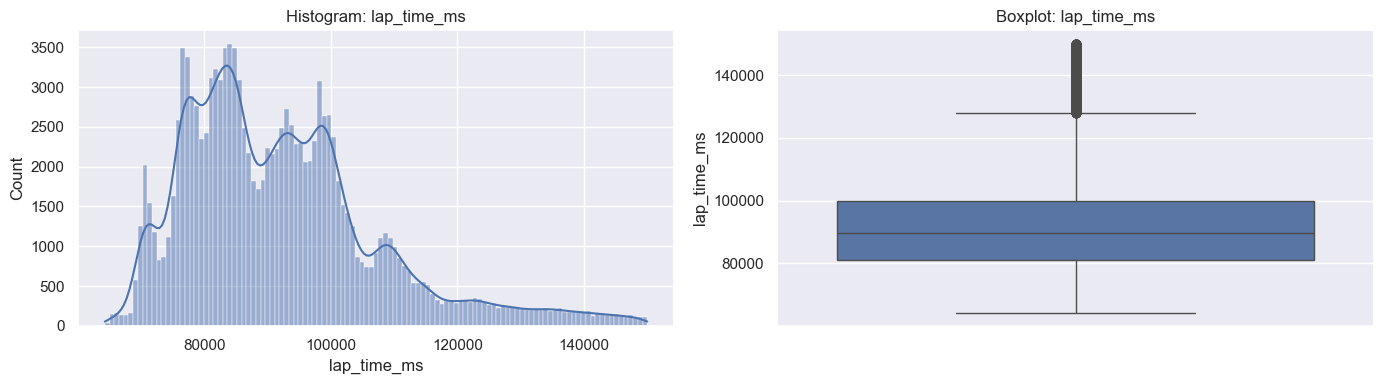

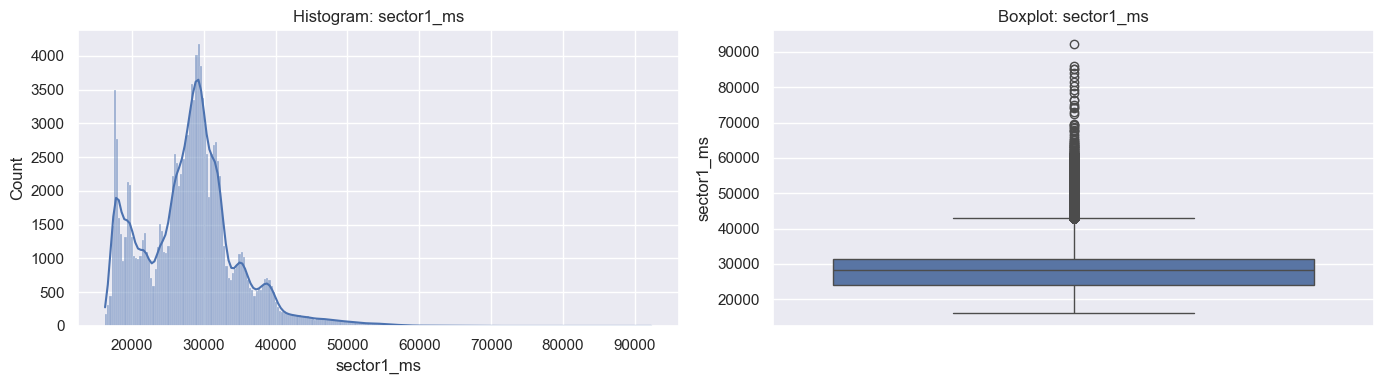

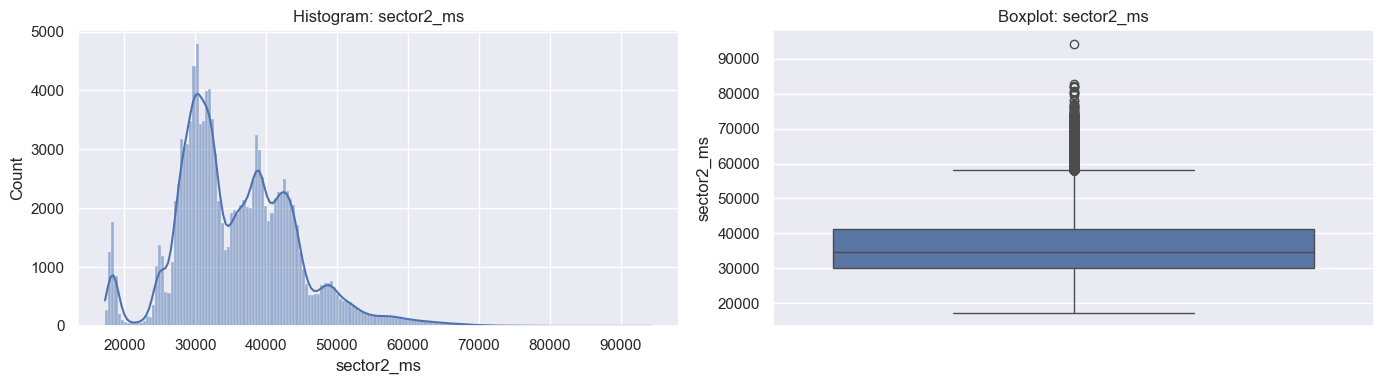

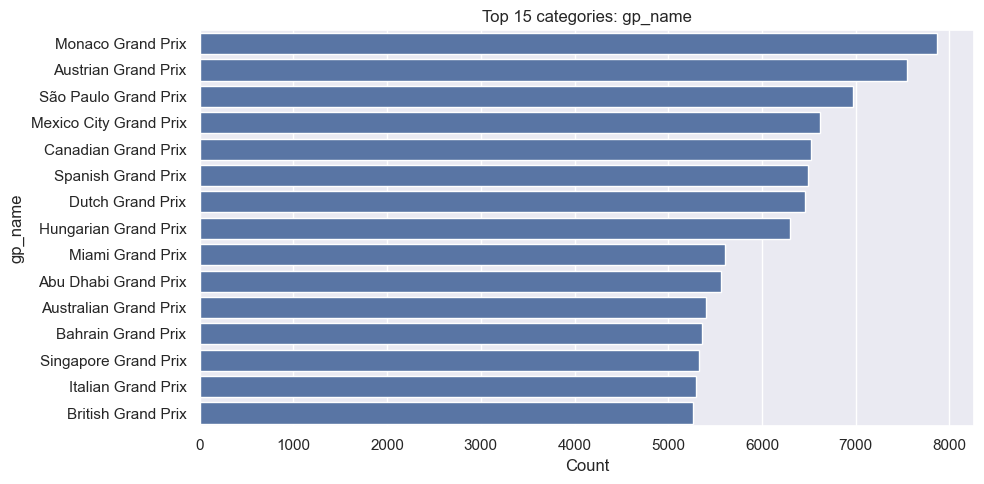

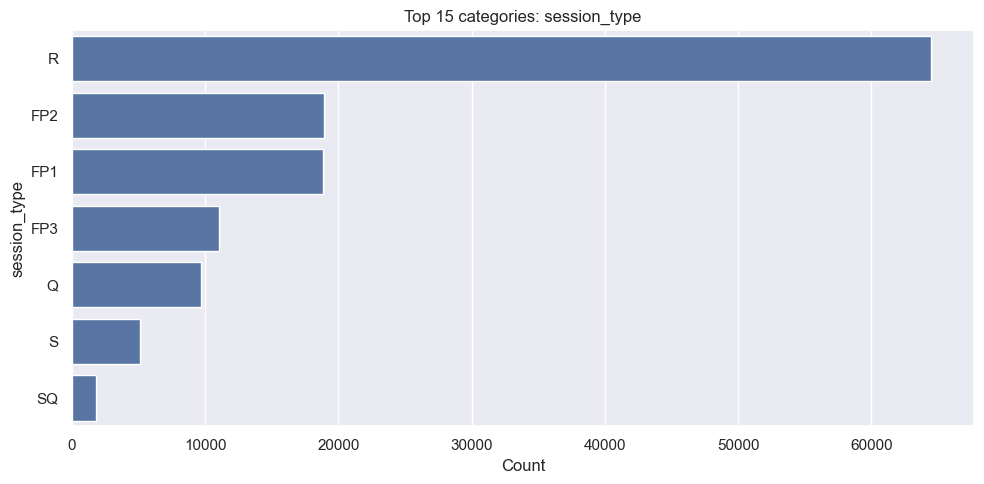

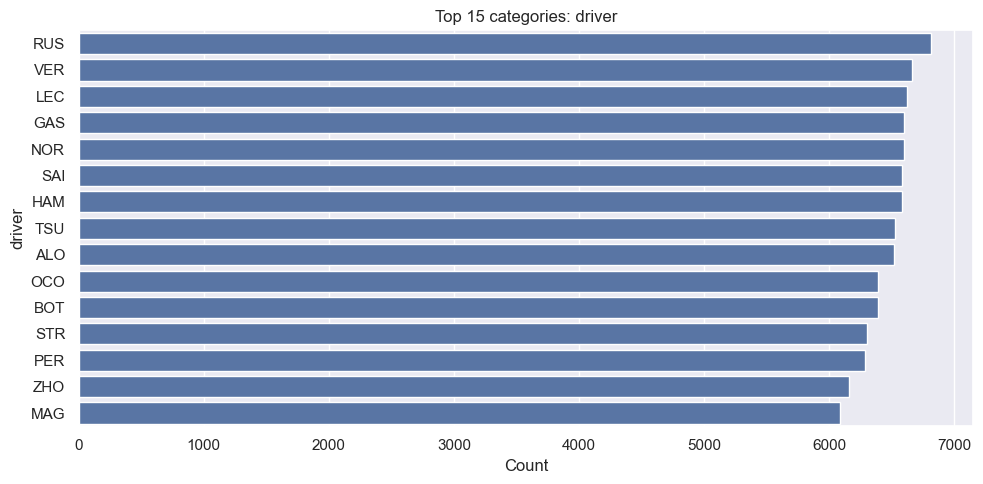

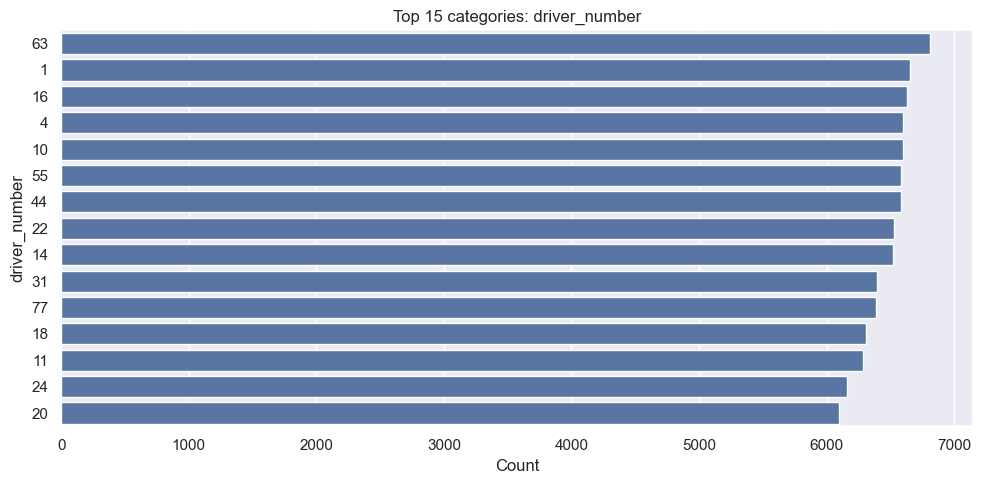

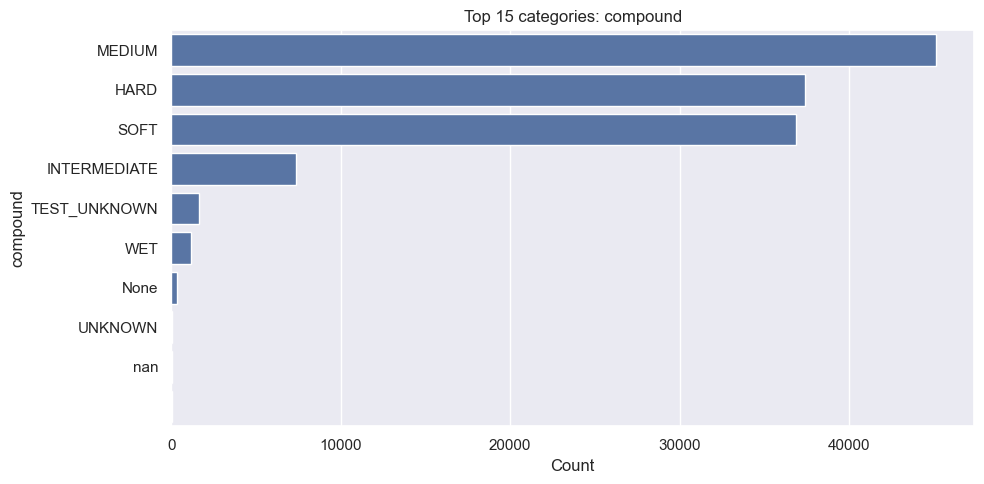

In [26]:
# Filter numeric columns with actual data (non-null count > 0)
valid_numeric = [c for c in numeric_cols if df[c].notna().sum() > 0]
max_numeric = valid_numeric[:6]

for col in max_numeric:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(data=df, x=col, kde=True, ax=axes[0])
    axes[0].set_title(f"Histogram: {col}")
    sns.boxplot(data=df, y=col, ax=axes[1])  # use y= for single-variable boxplot
    axes[1].set_title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()


def plot_top_categories(column: str, top: int = 15):
    counts = df[column].value_counts(dropna=False).head(top)
    if counts.empty:
        print(f"No data for {column}")
        return
    plt.figure(figsize=(10, 5))
    sns.barplot(x=counts.values, y=counts.index.astype(str))
    plt.title(f"Top {top} categories: {column}")
    plt.xlabel("Count")
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

for col in cat_cols[:5]:
    plot_top_categories(col)

## Missing values and data quality

Null counts, percentages, missingness heatmap sample, and simple outlier flags on numeric columns.

,missing,pct
position,59109,45.51
tyre_life,466,0.36
stint,12,0.01
session_id,0,0.00
driver,0,0.00
driver_number,0,0.00
lap_number,0,0.00
lap_time_ms,0,0.00
sector1_ms,0,0.00
year,0,0.00


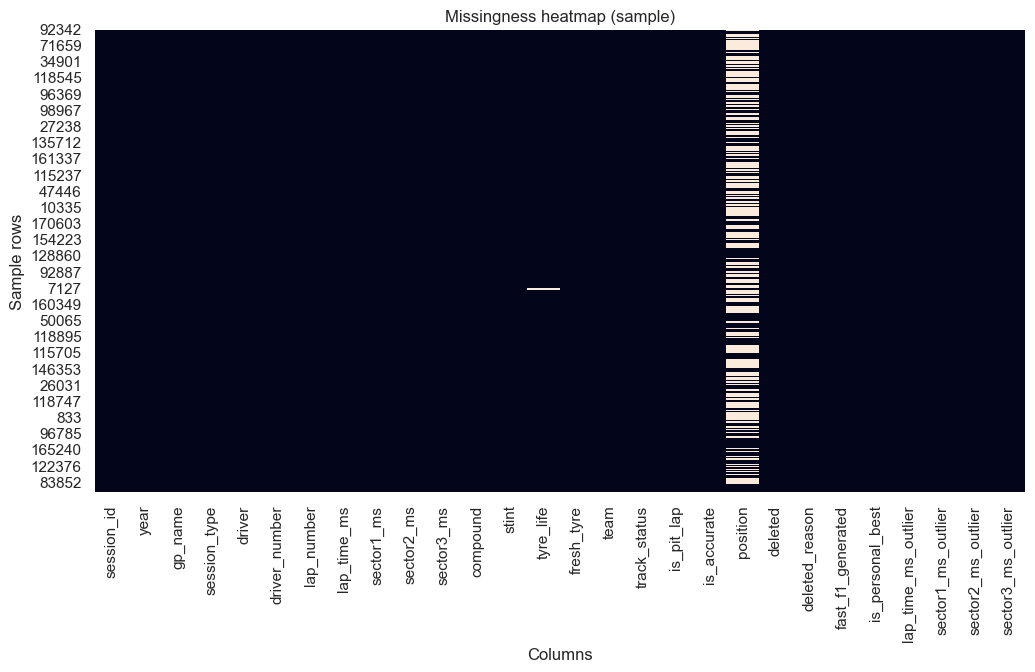

Outlier counts (IQR rule):


lap_time_ms    5092
tyre_life      4092
sector1_ms     3550
sector3_ms     3108
lap_number     2406
sector2_ms     1991
stint           480
dtype: int64

In [27]:
missing = df.isna().sum().to_frame("missing")
missing["pct"] = (missing["missing"] / len(df) * 100).round(2)
missing = missing.sort_values("missing", ascending=False)
display(missing.head(30))

sample_size = min(len(df), 400)
if sample_size > 0:
    sample = df.sample(sample_size, random_state=42)
    plt.figure(figsize=(12, 6))
    sns.heatmap(sample.isna(), cbar=False)
    plt.title("Missingness heatmap (sample)")
    plt.xlabel("Columns")
    plt.ylabel("Sample rows")
    plt.show()

outlier_counts = {}
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    if pd.isna(iqr) or iqr == 0:
        continue
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    if outliers:
        outlier_counts[col] = outliers

print("Outlier counts (IQR rule):")
display(pd.Series(outlier_counts).sort_values(ascending=False) if outlier_counts else "No outliers detected under IQR rule.")

## Sample records preview

Head, tail, and random samples to manually inspect data correctness.

In [28]:
display(df.head(10))
display(df.tail(10))
display(df.sample(10, random_state=123) if len(df) >= 10 else df.sample(len(df), random_state=123))

,session_id,year,gp_name,session_type,driver,driver_number,lap_number,lap_time_ms,sector1_ms,sector2_ms,sector3_ms,compound,stint,tyre_life,fresh_tyre,team,track_status,is_pit_lap,is_accurate,position,deleted,deleted_reason,fast_f1_generated,is_personal_best,lap_time_ms_outlier,sector1_ms_outlier,sector2_ms_outlier,sector3_ms_outlier
3,661656503,2022,Abu Dhabi Grand Prix,FP1,RIC,3,4,90759.0,18427.0,38636.0,33696.0,HARD,2.0,4.0,0,McLaren,1,0,1,NaN,0,,0,1,False,False,False,False
4,661656503,2022,Abu Dhabi Grand Prix,FP1,RIC,3,5,89445.0,18153.0,38149.0,33143.0,HARD,2.0,5.0,0,McLaren,1,0,1,NaN,0,,0,1,False,False,False,False
5,661656503,2022,Abu Dhabi Grand Prix,FP1,RIC,3,6,132859.0,23315.0,58746.0,50798.0,HARD,2.0,6.0,0,McLaren,1,0,1,NaN,0,,0,0,True,False,True,True
6,661656503,2022,Abu Dhabi Grand Prix,FP1,RIC,3,7,89035.0,18114.0,38152.0,32769.0,HARD,2.0,7.0,0,McLaren,1,0,1,NaN,0,,0,1,False,False,False,False
7,661656503,2022,Abu Dhabi Grand Prix,FP1,RIC,3,8,132252.0,24273.0,58161.0,49818.0,HARD,2.0,8.0,0,McLaren,1,0,1,NaN,0,,0,0,True,False,True,True
8,661656503,2022,Abu Dhabi Grand Prix,FP1,RIC,3,9,89528.0,18296.0,37972.0,33260.0,HARD,2.0,9.0,0,McLaren,1,0,1,NaN,0,,0,0,False,False,False,False
9,661656503,2022,Abu Dhabi Grand Prix,FP1,RIC,3,10,90972.0,18210.0,39153.0,33609.0,HARD,2.0,10.0,0,McLaren,1,0,1,NaN,0,,0,0,False,False,False,False
10,661656503,2022,Abu Dhabi Grand Prix,FP1,RIC,3,11,90794.0,18253.0,39104.0,33437.0,HARD,2.0,11.0,0,McLaren,12,0,1,NaN,0,,0,0,False,False,False,False
11,661656503,2022,Abu Dhabi Grand Prix,FP1,RIC,3,12,90919.0,18280.0,39188.0,33451.0,HARD,2.0,12.0,0,McLaren,1,0,1,NaN,0,,0,0,False,False,False,False
14,661656503,2022,Abu Dhabi Grand Prix,FP1,RIC,3,15,87619.0,17869.0,37602.0,32148.0,SOFT,3.0,2.0,1,McLaren,1,0,1,NaN,0,,0,1,False,False,False,False


,session_id,year,gp_name,session_type,driver,driver_number,lap_number,lap_time_ms,sector1_ms,sector2_ms,sector3_ms,compound,stint,tyre_life,fresh_tyre,team,track_status,is_pit_lap,is_accurate,position,deleted,deleted_reason,fast_f1_generated,is_personal_best,lap_time_ms_outlier,sector1_ms_outlier,sector2_ms_outlier,sector3_ms_outlier
182372,859185093,2024,United States Grand Prix,SQ,OCO,31,2,95178.0,25815.0,38169.0,31194.0,MEDIUM,1.0,2.0,1,Alpine,1,0,1,NaN,0,,0,1,False,False,False,False
182375,859185093,2024,United States Grand Prix,SQ,OCO,31,5,94917.0,25638.0,38063.0,31216.0,MEDIUM,2.0,5.0,0,Alpine,1,0,1,NaN,0,,0,1,False,False,False,False
182378,859185093,2024,United States Grand Prix,SQ,BOT,77,2,95884.0,26345.0,38073.0,31466.0,MEDIUM,1.0,2.0,1,Kick Sauber,1,0,1,NaN,0,,0,1,False,False,False,False
182381,859185093,2024,United States Grand Prix,SQ,BOT,77,5,95148.0,25743.0,38175.0,31230.0,MEDIUM,2.0,5.0,0,Kick Sauber,1,0,1,NaN,0,,0,1,False,False,False,False
182384,859185093,2024,United States Grand Prix,SQ,COL,43,2,95054.0,25443.0,38054.0,31557.0,MEDIUM,1.0,2.0,1,Williams,1,0,1,NaN,0,,0,1,False,False,False,False
182387,859185093,2024,United States Grand Prix,SQ,COL,43,5,94606.0,25499.0,37864.0,31243.0,MEDIUM,2.0,5.0,0,Williams,1,0,1,NaN,0,,0,1,False,False,False,False
182390,859185093,2024,United States Grand Prix,SQ,COL,43,8,93952.0,25373.0,37691.0,30888.0,MEDIUM,3.0,2.0,1,Williams,1,0,1,NaN,0,,0,1,False,False,False,False
182396,859185093,2024,United States Grand Prix,SQ,COL,43,14,94406.0,25614.0,37695.0,31097.0,SOFT,6.0,4.0,0,Williams,1,0,1,NaN,0,,0,1,False,False,False,False
182399,859185093,2024,United States Grand Prix,SQ,ZHO,24,2,96472.0,26381.0,38601.0,31490.0,MEDIUM,1.0,2.0,1,Kick Sauber,1,0,1,NaN,0,,0,1,False,False,False,False
182402,859185093,2024,United States Grand Prix,SQ,ZHO,24,5,95193.0,25772.0,38170.0,31251.0,MEDIUM,2.0,5.0,0,Kick Sauber,1,0,1,NaN,1,TRACK LIMITS AT TURN 19 LAP 6,0,0,False,False,False,False


,session_id,year,gp_name,session_type,driver,driver_number,lap_number,lap_time_ms,sector1_ms,sector2_ms,sector3_ms,compound,stint,tyre_life,fresh_tyre,team,track_status,is_pit_lap,is_accurate,position,deleted,deleted_reason,fast_f1_generated,is_personal_best,lap_time_ms_outlier,sector1_ms_outlier,sector2_ms_outlier,sector3_ms_outlier
147650,261819630,2024,Hungarian Grand Prix,FP1,OCO,31,4,81269.0,29446.0,28915.0,22908.0,MEDIUM,1.0,4.0,1,Alpine,1,0,1,NaN,0,,0,1,False,False,False,False
100109,807170493,2023,Monaco Grand Prix,FP1,HAM,44,21,76510.0,20126.0,36011.0,20373.0,MEDIUM,3.0,11.0,0,Mercedes,1,0,1,NaN,0,,0,0,False,False,False,False
146393,755188489,2024,Emilia Romagna Grand Prix,R,SAI,55,57,80759.0,25590.0,28203.0,26966.0,HARD,2.0,30.0,1,Ferrari,1,0,1,5.0,0,,0,0,False,False,False,False
65609,197690814,2023,Australian Grand Prix,R,ZHO,24,20,83666.0,29261.0,18639.0,35766.0,HARD,3.0,19.0,0,Alfa Romeo,1,0,1,13.0,0,,0,0,False,False,False,False
61985,743900703,2023,Abu Dhabi Grand Prix,FP3,HAM,44,12,91318.0,18567.0,39251.0,33500.0,SOFT,3.0,12.0,0,Mercedes,1,0,1,NaN,0,,0,0,False,False,False,False
25280,133201226,2022,Emilia Romagna Grand Prix,FP2,LEC,16,7,81845.0,26039.0,28490.0,27316.0,MEDIUM,2.0,7.0,0,Ferrari,1,0,1,NaN,0,,0,0,False,False,False,False
78903,734196188,2023,Canadian Grand Prix,Q,NOR,4,10,81998.0,23540.0,26349.0,32109.0,INTERMEDIATE,2.0,8.0,1,McLaren,1,0,1,NaN,0,,0,1,False,False,False,False
118991,19806254,2024,Abu Dhabi Grand Prix,FP2,STR,18,2,86822.0,17960.0,36930.0,31932.0,MEDIUM,1.0,2.0,1,Aston Martin,1,0,1,NaN,0,,0,1,False,False,False,False
77542,388189533,2023,British Grand Prix,R,BOT,77,30,93367.0,29967.0,37720.0,25680.0,HARD,1.0,30.0,1,Alfa Romeo,1,0,1,13.0,0,,0,0,False,False,False,False
54055,739460851,2022,Spanish Grand Prix,R,MSC,47,2,89013.0,24642.0,33728.0,30643.0,SOFT,1.0,4.0,0,Haas F1 Team,1,0,1,6.0,0,,0,1,False,False,False,False


## Persist processed outputs (optional)

Save filtered subsets or profiling outputs for downstream modeling.

In [29]:
output_dir = PROJECT_ROOT / "data" / "cache" / "eda"
output_dir.mkdir(parents=True, exist_ok=True)

subset_cols = numeric_cols[:5] + cat_cols[:5]
subset = df[subset_cols] if subset_cols else df.copy()

parquet_path = output_dir / "eda_sample.parquet"
csv_path = output_dir / "eda_sample.csv"

subset.to_parquet(parquet_path, index=False)
subset.to_csv(csv_path, index=False)

print("Saved EDA subset to:")
print(parquet_path.relative_to(PROJECT_ROOT))
print(csv_path.relative_to(PROJECT_ROOT))

Saved EDA subset to:
data\cache\eda\eda_sample.parquet
data\cache\eda\eda_sample.csv
